<a href="https://colab.research.google.com/github/mayur07699/MLDS/blob/main/SimpleLinear15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [14]:
df = pd.read_csv('/IPLPlayerStat-1.csv')

In [15]:
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [16]:
df.columns

Index(['Unnamed: 0', 'player', 'runs', 'boundaries', 'balls_faced', 'wickets',
       'balls_bowled', 'runs_conceded', 'matches', 'batting_avg',
       'batting_strike_rate', 'boundaries_percent', 'bowling_economy',
       'bowling_avg', 'bowling_strike_rate', 'catches', 'stumpings'],
      dtype='object')

In [17]:
df.isna().sum()

,0
Unnamed: 0,0
player,0
runs,0
boundaries,0
balls_faced,0
wickets,0
balls_bowled,0
runs_conceded,0
matches,0
batting_avg,0


In [18]:
if 'Unnamed: 0' in df.columns:
   df = df.drop(columns=['Unnamed: 0'])

In [19]:
df

,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,Yash Dayal,0,0,1,11.0,205.0,296.0,9,0.00,0.00,0.00,8.66,26.91,18.64,1.0,0.0
601,Yashpal Singh,47,5,67,0.0,0.0,0.0,4,11.75,70.15,7.46,0.00,0.00,0.00,3.0,0.0
602,Younis Khan,3,0,7,0.0,0.0,0.0,1,3.00,42.86,0.00,0.00,0.00,0.00,1.0,0.0
603,Yuvraj Singh,2754,367,2207,36.0,882.0,1091.0,129,21.35,124.78,16.63,7.42,30.31,24.50,29.0,0.0


In [20]:
df['balls_faced'].describe()

,balls_faced
count,605.000000
mean,373.477686
std,764.432561
min,1.000000
25%,18.000000
50%,73.000000
75%,285.000000
max,5266.000000


In [33]:
X = df[['balls_faced']]
Y = df['runs']          # <-- Series (1D)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, Y_train)

y_predict = model.predict(X_test)

/tmp/ipykernel_1613/1397315500.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


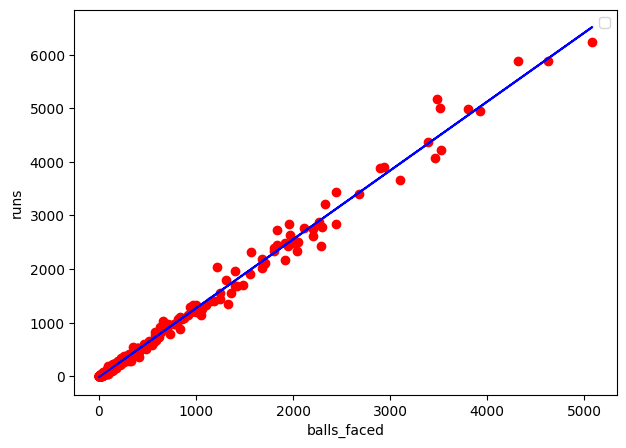

In [34]:
plt.figure(figsize=(7,5))
plt.scatter(X_train,Y_train,color='red')
plt.plot(X_train,model.predict(X_train),color='blue')
plt.xlabel('balls_faced')
plt.ylabel('runs')
plt.legend()

In [37]:
y_predict = model.predict(X_test).ravel()

comparison = pd.DataFrame({
    "balls_faced": X_test["balls_faced"].values,
    "actual_runs": Y_test.values.ravel(),
    "predicted_runs": np.round(y_predict, 1)
})
comparison.head(10)

,balls_faced,actual_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6
5,865,985,1095.6
6,26,34,18.1
7,9,12,-3.8
8,18,20,7.8
9,703,920,887.6


In [29]:
print(type(Y_test), Y_test.shape)
print(type(y_predict), y_predict.shape)

<class 'pandas.core.frame.DataFrame'> (121, 1)
<class 'numpy.ndarray'> (121, 1)
